# Imports & Load Model

In [1]:
from transformers import pipeline
import pandas as pd

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

d:\customer-review-summarization\env\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SourceCode\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

# Load Processed Data

In [2]:
df = pd.read_csv("../data/processed/test.csv")
df.head()


,product_name,product_price,Rate,Review,Summary,Sentiment,sentiment_label
0,Flipkart SmartBuy CFXB18 Electric Rice Cooker?...,1599,5,super!,good,positive,2
1,Dettol Effective Protection Antiseptic LiquidÐ...,349,5,must buy!,very good product,positive,2
2,DOMS Pencil Smart Kit,449,5,worth every penny,its very good and all are bright colors,positive,2
3,Fun and Flex Solid Jungle Theme Animal Face Fo...,268,2,expected a better product,very bad all baloon r based,negative,0
4,HP 680 Black Ink Cartridge,852,5,great product,fantastic,positive,2


# Predict Sentiment on Sample Reviews

In [4]:
sample_reviews = df['Review'].sample(10).tolist()

results = sentiment_pipeline(sample_reviews)

for review, result in zip(sample_reviews, results):
    print("Review:", review[:120], "...")
    print("Prediction:", result)
    print("-" * 60)


Review: simply awesome ...
Prediction: {'label': 'POSITIVE', 'score': 0.9998732805252075}
------------------------------------------------------------
Review: nice product ...
Prediction: {'label': 'POSITIVE', 'score': 0.9998539686203003}
------------------------------------------------------------
Review: slightly disappointed ...
Prediction: {'label': 'NEGATIVE', 'score': 0.9997597336769104}
------------------------------------------------------------
Review: nice ...
Prediction: {'label': 'POSITIVE', 'score': 0.9998552799224854}
------------------------------------------------------------
Review: mind-blowing purchase ...
Prediction: {'label': 'POSITIVE', 'score': 0.9992690682411194}
------------------------------------------------------------
Review: awesome ...
Prediction: {'label': 'POSITIVE', 'score': 0.9998682737350464}
------------------------------------------------------------
Review: not recommended at all ...
Prediction: {'label': 'NEGATIVE', 'score': 0.9997100234031677}
-

# Sentiment Distribution (Predicted)

<Axes: title={'center': 'Predicted Sentiment Distribution'}>

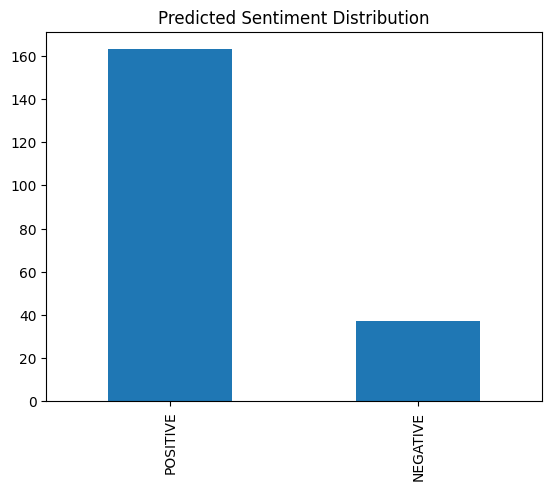

In [5]:
predictions = sentiment_pipeline(df['Review'].head(200).tolist())
labels = [p['label'] for p in predictions]

pd.Series(labels).value_counts().plot(kind='bar', title="Predicted Sentiment Distribution")


# Save Experimental Results (Optional)

In [6]:
df_exp = df.head(200).copy()
df_exp['predicted_sentiment'] = labels
df_exp.to_csv("../results/metrics/sentiment_experiment_samples.csv", index=False)
